In [ ]:
# 安装第三方库

In [ ]:
pip install pdfplumber

In [ ]:
pip install wordcloud

In [ ]:
pip install openpyxl

In [ ]:
# 数据预处理

In [ ]:
df.to_csv('特医食品说明书数据.csv', index=False, encoding='utf-8')

In [76]:
# Step 1: 导入必要的库
import pandas as pd
import numpy as np

# Step 2: 读取 Excel 文件
file_path = r"D:\python练习\泰迪杯数据分析B\数据\data.xlsx"
df = pd.read_excel(file_path)

# Step 3: 查看和理解数据
df.head()         # 查看前几行数据

,企业名称,产品名称,注册证号,有效期至
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17


In [77]:
df.info()          # 查看数据框的信息，包括列名、非空值数量和数据类型

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   企业名称    182 non-null    object        
 1   产品名称    182 non-null    object        
 2   注册证号    182 non-null    object        
 3   有效期至    182 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 5.8+ KB


In [78]:
df.describe()      # 查看数值型列的统计信息

,有效期至
count,182
mean,2027-06-10 20:10:32.967033088
min,2022-11-19 00:00:00
25%,2026-04-11 00:00:00
50%,2028-03-14 00:00:00
75%,2028-11-13 00:00:00
max,2029-04-01 00:00:00


In [79]:
df.isnull().sum()  # 查看每列的缺失值数量

企业名称    0
产品名称    0
注册证号    0
有效期至    0
dtype: int64

In [10]:
from scipy import stats

# 计算每列的 Z-score
z_scores = stats.zscore(df.select_dtypes(include=[np.number]))

# 定义一个阈值，通常为 3
threshold = 3

# 标记异常值
outliers = (np.abs(z_scores) > threshold).any(axis=1)
print(outliers.sum())  # 打印异常值的数量

0


In [80]:
def detect_outliers_combined(df):
    outliers = pd.DataFrame()
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        z_scores = stats.zscore(df[column])
        combined_outliers = ((df[column] < lower_bound) | (df[column] > upper_bound) | (np.abs(z_scores) > 3))
        outliers[column] = combined_outliers
    return outliers

# 检测异常值
combined_outliers = detect_outliers_combined(df)
print(combined_outliers.sum())  # 打印每列的异常值数量


Series([], dtype: float64)


In [81]:
# 检查每列的空值数量
null_counts = df.isnull().sum()
print(null_counts)


企业名称    0
产品名称    0
注册证号    0
有效期至    0
dtype: int64


In [82]:
import pandas as pd

# 检查是否存在重复值
duplicates = df.duplicated()
print("原始数据的重复值情况：")
print(duplicates)

# 统计重复值的数量
num_duplicates = duplicates.sum()
print(f"存在 {num_duplicates} 行重复")

原始数据的重复值情况：
0      False
1      False
2      False
3      False
4      False
       ...  
177    False
178    False
179    False
180    False
181    False
Length: 182, dtype: bool
存在 0 行重复


In [ ]:
# 任务1.1

In [83]:
import pdfplumber
import pandas as pd
import os
import re

# 文件夹路径
folder_path = r"D:\python练习\泰迪杯数据分析B\数据\特医食品说明书"

# 要提取的营养成分及对应的列名
nutrient_mapping = {
    '能量': '能量(kJ)',
    '脂肪': '脂肪(g)',
    '碳水化合物': '碳水化合物(g)',
    '蛋白质': '蛋白质(g)',
    '钠': '钠(mg)',
    '氯': '氯(mg)',
    '钾': '钾(mg)',
    '磷': '磷(mg)',
}

# 初始化一个空的列表，用于存储所有的结果
results = []

# 获取文件夹中所有的PDF文件
pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

for pdf_file in pdf_files:
    file_path = os.path.join(folder_path, pdf_file)
    # 提取注册证号，假设文件名就是注册证号
    registration_number = os.path.splitext(pdf_file)[0]

    # 初始化一个空的列表，用于存储所有的DataFrame
    dfs = []
    # 保存最新的表头
    last_header = None

    # 打开 PDF 文件
    with pdfplumber.open(file_path) as pdf:
        table_found = False  # 标记是否找到表格
        # 遍历每一页
        for page_num, page in enumerate(pdf.pages):
            # 尝试提取所有表格
            tables = page.extract_tables()
            if tables:
                table_found = True
                for idx, table in enumerate(tables):
                    # 如果表格为空，跳过
                    if not table or len(table) == 0:
                        continue
                    # 检查表格的第一行是否是表头
                    first_row = table[0]
                    # 判断条件可以根据实际情况调整
                    if '营养成分' in first_row or '每100g' in first_row:
                        # 认为第一行是表头，保存表头
                        last_header = first_row
                        data_rows = table[1:]  # 数据行
                    else:
                        # 没有表头，使用之前保存的表头
                        if last_header is not None:
                            data_rows = table
                        else:
                            print(f"文件 {pdf_file} 第 {page_num+1} 页，第 {idx+1} 个表格缺少表头且没有之前的表头可用，跳过该表格。")
                            continue  # 跳过该表格
                
                    # 调整数据行，使其与表头的列数匹配
                    adjusted_data_rows = []
                    for row in data_rows:
                        # 如果行的长度与表头长度一致，直接添加
                        if len(row) == len(last_header):
                            adjusted_data_rows.append(row)
                        elif len(row) == 1:
                            # 尝试拆分单个字符串为多个列
                            split_row = re.split(r'\s+', row[0].strip())
                            if len(split_row) == len(last_header):
                                adjusted_data_rows.append(split_row)
                            else:
                                continue
                        else:
                            print(f"行的列数 {len(row)} 与表头列数 {len(last_header)} 不匹配，跳过该行：{row}")
                            continue
                
                    # 如果调整后的数据行为空，跳过该表格
                    if not adjusted_data_rows:
                        print(f"文件 {pdf_file} 第 {page_num+1} 页，第 {idx+1} 个表格的数据行无法匹配表头，跳过该表格。")
                        continue
                
                    # 现在创建 DataFrame
                    df = pd.DataFrame(adjusted_data_rows, columns=last_header)
                    # 将 DataFrame 添加到列表中
                    dfs.append(df)
            else:
                print(f"在文件 {pdf_file} 第 {page_num+1} 页未找到表格。")
        if not table_found:
            print(f"在文件 {pdf_file} 中未找到任何表格。")
            continue  # 跳过该PDF文件

    # 合并所有的DataFrame
    if dfs:
        try:
            combined_df = pd.concat(dfs, ignore_index=True)
        except Exception as e:
            print(f"在合并文件 {pdf_file} 的表格时发生错误: {e}")
            continue  # 跳过该PDF文件

        # 清理列名，去除可能的空格和特殊字符
        combined_df.columns = combined_df.columns.astype(str)
        combined_df.columns = combined_df.columns.str.strip().str.replace('\n', '').str.replace(' ', '')
        if '营养成分' not in combined_df.columns:
            print(f"在文件 {pdf_file} 的合并表格中未找到 '营养成分' 列，实际的列名是: {combined_df.columns.tolist()}")
            continue  # 跳过这个PDF文件

        try:
            # 清理数据行，去除可能的空格和特殊字符
            combined_df['营养成分'] = combined_df['营养成分'].astype(str).str.strip().str.replace('\n', '').str.replace(' ', '')
            # 去除'营养成分'中的括号及其中内容
            combined_df['营养成分_clean'] = combined_df['营养成分'].str.replace(r'（.*?）', '', regex=True)
            combined_df['营养成分_clean'] = combined_df['营养成分_clean'].str.replace(r'\(.*?\)', '', regex=True)
            combined_df['营养成分_clean'] = combined_df['营养成分_clean'].str.strip()

            # 初始化数据字典
            data = {'注册证号': registration_number}
            for nutrient_chinese, column_name in nutrient_mapping.items():
                # 找到对应的行，使用精确匹配
                matching_rows = combined_df[combined_df['营养成分_clean'] == nutrient_chinese]
                if not matching_rows.empty:
                    # 获取 '每100kJ' 列的值，并去除可能的空格
                    value = matching_rows['每100kJ'].values[0]
                    if isinstance(value, str):
                        value = value.strip()
                    data[column_name] = value
                else:
                    data[column_name] = None  # 如果没有找到，填充None
                    print(f"文件 {pdf_file} 未找到营养成分 {nutrient_chinese}")
            # 把结果添加到列表
            results.append(data)
        except Exception as e:
            print(f"在处理文件 {pdf_file} 时发生错误: {e}")
    else:
        print(f"在文件 {pdf_file} 中未找到任何表格。")

# 创建最终的 DataFrame
final_df = pd.DataFrame(results)

# 将列按照指定顺序排列
column_order = ['注册证号'] + list(nutrient_mapping.values())
final_df = final_df[column_order]

# 输出结果
print(final_df)


在文件 国食注字TY20175001.pdf 第 4 页未找到表格。
在文件 国食注字TY20175002.pdf 第 4 页未找到表格。
文件 国食注字TY20175003.pdf 第 1 页，第 1 个表格缺少表头且没有之前的表头可用，跳过该表格。
文件 国食注字TY20175003.pdf 第 2 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20175003.pdf 第 3 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
行的列数 5 与表头列数 4 不匹配，跳过该行：['建\n议\n喂\n哺\n表', '婴儿年龄', '每次喂哺量', None, '每24小时喂哺次数']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, None, '煮沸过的温开水（毫升）', '量匙数量', None]
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '0-2周', '60', '1', '8-10']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '2周-2月', '120', '2', '6-7']
行的列数 5 与表头列数 4 不匹配，跳过该行：[None, '2月-6月', '180', '3', '5-6']
文件 国食注字TY20175003.pdf 第 3 页，第 3 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20175003.pdf 第 4 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
行的列数 5 与表头列数 4 不匹配，跳过该行：['', '6月-12月', '180', '3', '4-5']
文件 国食注字TY20175003.pdf 第 4 页，第 2 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 1 页，第 1 个表格缺少表头且没有之前的表头可用，跳过该表格。
文件 国食注字TY20180001.pdf 第 2 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 3 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180001.pdf 第 4 页，第 1 个表格的数据行无法匹配表头，跳过该表格。
文件 国食注字TY20180

In [85]:
final_df.to_excel('result1.xlsx',index=False)
final_df

,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
0,国食注字TY20175001,100,1.2,2.5,0.72,10.1,20.8,28.5,21.3
1,国食注字TY20175002,100,1.28,2.51,0.55,9,15,32,15
2,国食注字TY20175003,100.0,1.280,2.549,0.546,,15.38,31.47,10.49
3,国食注字TY20180001,100,1.3,2.6,0.56,8.4,15.4,24.7,13.1
4,国食注字TY20180002,100,0,5.8,0,271,416,184,14.6
...,...,...,...,...,...,...,...,...,...
176,国食注字TY20240018,100,0.76,3.15,0.95,23,18,32,11
177,国食注字TY20240019,100,0,0.3,5.6,11,None,None,None
178,国食注字TY20240020,100,2.3,0.69,0.22,3.2,None,None,None
179,国食注字TY20240021,100,0,5.71,0.18,14.17,None,None,None


In [86]:
 file_path = r"D:\python练习\泰迪杯数据分析B\result1.xlsx"
data = pd.read_excel(file_path)
data

,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
0,国食注字TY20175001,100.0,1.20,2.500,0.720,10.10,20.80,28.50,21.30
1,国食注字TY20175002,100.0,1.28,2.510,0.550,9.00,15.00,32.00,15.00
2,国食注字TY20175003,100.0,1.28,2.549,0.546,NaN,15.38,31.47,10.49
3,国食注字TY20180001,100.0,1.30,2.600,0.560,8.40,15.40,24.70,13.10
4,国食注字TY20180002,100.0,0.00,5.800,0.000,271.00,416.00,184.00,14.60
...,...,...,...,...,...,...,...,...,...
176,国食注字TY20240018,100.0,0.76,3.150,0.950,23.00,18.00,32.00,11.00
177,国食注字TY20240019,100.0,0.00,0.300,5.600,11.00,NaN,NaN,NaN
178,国食注字TY20240020,100.0,2.30,0.690,0.220,3.20,NaN,NaN,NaN
179,国食注字TY20240021,100.0,0.00,5.710,0.180,14.17,NaN,NaN,NaN


In [87]:
data.info()          # 查看数据框的信息，包括列名、非空值数量和数据类型

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   注册证号      181 non-null    object 
 1   能量(kJ)    179 non-null    float64
 2   脂肪(g)     179 non-null    float64
 3   碳水化合物(g)  179 non-null    float64
 4   蛋白质(g)    179 non-null    float64
 5   钠(mg)     180 non-null    float64
 6   氯(mg)     135 non-null    float64
 7   钾(mg)     133 non-null    float64
 8   磷(mg)     126 non-null    float64
dtypes: float64(8), object(1)
memory usage: 12.9+ KB


In [88]:
data.describe()      # 查看数值型列的统计信息

,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
count,179.0,179.000000,179.000000,179.000000,180.000000,135.000000,133.000000,126.000000
mean,100.0,0.623939,3.299866,1.190408,57.738950,95.802741,58.615263,17.450159
std,0.0,0.524114,1.741993,1.594613,143.294753,224.081222,77.644981,12.233709
min,100.0,0.000000,0.007000,0.000000,0.000000,0.720000,0.240000,7.990000
25%,100.0,0.000000,2.500000,0.225000,9.000000,15.800000,26.000000,12.025000
50%,100.0,0.740000,3.000000,0.720000,20.850000,20.000000,32.000000,14.550000
75%,100.0,1.170000,4.615000,1.100000,25.850000,29.200000,37.000000,17.000000
max,100.0,2.300000,6.200000,5.900000,750.000000,1003.500000,363.000000,109.000000


In [14]:
data.isnull().sum()  # 查看每列的缺失值数量

注册证号        0
能量(kJ)      2
脂肪(g)       2
碳水化合物(g)    2
蛋白质(g)      2
钠(mg)       0
氯(mg)       0
钾(mg)       0
磷(mg)       0
dtype: int64

In [89]:
from scipy import stats

# 计算每列的 Z-score
z_scores = stats.zscore(df.select_dtypes(include=[np.number]))

# 定义一个阈值，通常为 3
threshold = 3

# 标记异常值
outliers = (np.abs(z_scores) > threshold).any(axis=1)
print(outliers.sum())  # 打印异常值的数量

0


In [90]:
def detect_outliers_combined(data):
    outliers = pd.DataFrame()
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        z_scores = stats.zscore(df[column])
        combined_outliers = ((df[column] < lower_bound) | (df[column] > upper_bound) | (np.abs(z_scores) > 3))
        outliers[column] = combined_outliers
    return outliers

# 检测异常值
combined_outliers = detect_outliers_combined(data)
print(combined_outliers.sum())  # 打印每列的异常值数量


Series([], dtype: float64)


In [17]:
import pandas as pd

# 检查是否存在重复值
duplicates = data.duplicated()
print("原始数据的重复值情况：")
print(duplicates)

# 统计重复值的数量
num_duplicates = duplicates.sum()
print(f"存在 {num_duplicates} 行重复")

原始数据的重复值情况：
0      False
1      False
2      False
3      False
4      False
       ...  
176    False
177    False
178    False
179    False
180    False
Length: 181, dtype: bool
存在 0 行重复


In [91]:
# 检查每列的空值数量
null_counts = data.isnull().sum()
print(null_counts)


注册证号         0
能量(kJ)       2
脂肪(g)        2
碳水化合物(g)     2
蛋白质(g)       2
钠(mg)        1
氯(mg)       46
钾(mg)       48
磷(mg)       55
dtype: int64


In [19]:
data

,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
0,国食注字TY20175001,100.0,1.20,2.500,0.720,10.10,20.80,28.50,21.30
1,国食注字TY20175002,100.0,1.28,2.510,0.550,9.00,15.00,32.00,15.00
2,国食注字TY20175003,100.0,1.28,2.549,0.546,0.00,15.38,31.47,10.49
3,国食注字TY20180001,100.0,1.30,2.600,0.560,8.40,15.40,24.70,13.10
4,国食注字TY20180002,100.0,0.00,5.800,0.000,271.00,416.00,184.00,14.60
...,...,...,...,...,...,...,...,...,...
176,国食注字TY20240018,100.0,0.76,3.150,0.950,23.00,18.00,32.00,11.00
177,国食注字TY20240019,100.0,0.00,0.300,5.600,11.00,0.00,0.00,0.00
178,国食注字TY20240020,100.0,2.30,0.690,0.220,3.20,0.00,0.00,0.00
179,国食注字TY20240021,100.0,0.00,5.710,0.180,14.17,0.00,0.00,0.00


In [92]:
import pandas as pd
import os
file_path = r"D:\python练习\泰迪杯数据分析B\result1.xlsx"  
df = pd.read_excel(file_path)

# 打印列名以进行调试
print("原始列名:", df.columns)

# 去除列名前后的空格
df.columns = df.columns.str.strip()

# 再次打印列名以进行调试
print("去除空格后的列名:", df.columns)

# 定义需要检查的列名列表
columns_to_check = ['钠(mg)', '钾(mg)', '氯(mg)', '磷(mg)']

# 遍历每一列，将空值替换为0
for column in columns_to_check:
    if column in df.columns:
        df[column] = df[column].fillna(0)
    else:
        print(f"列 '{column}' 不存在于 DataFrame 中")

# 保存修改后的DataFrame到新的Excel文件
output_file_path = r"D:\python练习\泰迪杯数据分析B\result新.xlsx"  # 指定输出文件路径
print(f"正在保存到文件: {output_file_path}")
df.to_excel(output_file_path, index=False, engine='openpyxl')

print("数据修改完成，并已保存到新的Excel文件中。")



原始列名: Index(['注册证号', '能量(kJ)', '脂肪(g)', '碳水化合物(g)', '蛋白质(g)', '钠(mg)', '氯(mg)',
       '钾(mg)', '磷(mg)'],
      dtype='object')
去除空格后的列名: Index(['注册证号', '能量(kJ)', '脂肪(g)', '碳水化合物(g)', '蛋白质(g)', '钠(mg)', '氯(mg)',
       '钾(mg)', '磷(mg)'],
      dtype='object')
正在保存到文件: D:\python练习\泰迪杯数据分析B\result新.xlsx
数据修改完成，并已保存到新的Excel文件中。


In [9]:
final_df = pd.read_excel('result新.xlsx')
# 将蛋白质列转换为数值类型，处理可能的非数值字符
final_df['蛋白质(g)'] = pd.to_numeric(final_df['蛋白质(g)'], errors='coerce')

# 按蛋白质含量降序排序，并提取前三个数据
top_protein_df = final_df.sort_values(by='蛋白质(g)', ascending=False).head(3)

top_protein_df

,注册证号,能量(kJ),脂肪(g),碳水化合物(g),蛋白质(g),钠(mg),氯(mg),钾(mg),磷(mg)
133,国食注字TY20230045,100.0,0.04,0.007,5.9,45.0,0.0,0.0,0.0
150,国食注字TY20230062,100.0,0.00,0.080,5.8,24.0,0.0,0.0,0.0
78,国食注字TY20220002,100.0,0.00,0.100,5.8,80.4,0.0,0.0,0.0


In [ ]:
# 任务1.2

In [61]:
import os
import pandas as pd
import pdfplumber

# PDF 文件夹路径
pdf_folder = r"D:\python练习\泰迪杯数据分析B\数据\特医食品说明书"

# 读取 data.xlsx 数据
data_file = r"D:\python练习\泰迪杯数据分析B\数据\data.xlsx" 
data_df = pd.read_excel(data_file)

# 在 DataFrame 中新增三列
data_df['产品类别'] = None
data_df['组织状态'] = None
data_df['适用人群'] = None

# 用于存储无法提取的 PDF 文件路径
failed_pdfs = []

# 遍历 DataFrame 的每一行
for index, row in data_df.iterrows():
    registration_number = row['注册证号']  # 假设注册证号的列名为 '注册证号'
    # 根据注册证号找到对应的 PDF 文件
    pdf_file_name = registration_number + '.pdf'
    pdf_path = os.path.join(pdf_folder, pdf_file_name)
    
    # 检查 PDF 文件是否存在
    if not os.path.exists(pdf_path):
        print(f"PDF 文件不存在: {pdf_path}")
        failed_pdfs.append(pdf_path)
        continue  # 跳过这个文件
    
    try:
        with pdfplumber.open(pdf_path) as pdf:
            # 初始化提取的字段
            product_category = None  # 产品类别
            physical_state = None    # 组织状态
            suitable_population = None  # 适用人群
            # 标记是否成功提取所有字段
            success = True
            # 遍历 PDF 的每一页
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    lines = text.split('\n')
                    for line in lines:
                        line = line.strip()
                        # 提取 '产品类别'
                        if ('产品类别' in line or '产品类别：' in line or '产品类别:' in line) and not product_category:
                            parts = line.split('产品类别')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                product_category = content
                        # 提取 '组织状态'
                        if ('组织状态' in line or '组织状态：' in line or '组织状态:' in line) and not physical_state:
                            parts = line.split('组织状态')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                physical_state = content
                        # 提取 '适用人群'
                        if ('适用人群' in line or '适用人群：' in line or '适用人群:' in line) and not suitable_population:
                            parts = line.split('适用人群')
                            if len(parts) > 1:
                                content = parts[1].strip()
                                content = content.lstrip('：:').strip()
                                suitable_population = content
                # 如果已经提取到所有字段，可以停止遍历
                if product_category and physical_state and suitable_population:
                    break
            # 检查是否成功提取所有字段
            if not product_category or not physical_state or not suitable_population:
                print(f"未能从文件 {pdf_path} 提取所有字段")
                failed_pdfs.append(pdf_path)
                success = False
            # 如果成功，更新 DataFrame
            if success:
                data_df.at[index, '产品类别'] = product_category
                data_df.at[index, '组织状态'] = physical_state
                data_df.at[index, '适用人群'] = suitable_population
    except Exception as e:
        print(f"处理文件 {pdf_path} 时发生错误: {e}")
        failed_pdfs.append(pdf_path)

# 保存结果到 result2.xlsx
output_file = r"result2.xlsx"  # 请将此路径替换为您希望保存结果的路径
data_df.to_excel(output_file, index=False)

# 输出无法提取的 PDF 文件路径
if failed_pdfs:
    print("以下 PDF 文件未能提取到所有字段：")
    for pdf in failed_pdfs:
        print(pdf)
else:
    print("所有 PDF 文件均成功提取。")


所有 PDF 文件均成功提取。


In [93]:
# 去除“产品类别”、“组织状态”、“适用人群”列中的无效符号
data_df['产品类别'] = data_df['产品类别'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df['组织状态'] = data_df['组织状态'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df['适用人群'] = data_df['适用人群'].astype(str).str.replace(r'】|\n|\s', '', regex=True)
data_df.to_excel(r'result2.xlsx',index=False)
data_df.head()

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿,特医婴配食品,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿,特医婴配食品,国产产品,2018
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿,特医婴配食品,进口产品,2018


In [ ]:
# 任务1.3

In [94]:
import pandas as pd

# 读取 result2.xlsx 文件
file_path = "result2.xlsx"
data_df = pd.read_excel(file_path)

# 新增“适用人群类别”列，初始值为 None
data_df['适用人群类别'] = None

# 根据“适用人群”信息进行归类
def categorize_population(row):
    suitable_population = str(row['适用人群'])
    if '婴儿' in suitable_population or '0-12月龄' in suitable_population:
        return '特医婴配食品'
    else:
        return '1岁以上特医食品'

# 应用归类规则
data_df['适用人群类别'] = data_df.apply(categorize_population, axis=1)

# 保存结果到 result2.xlsx
output_file = r"D:\python练习\泰迪杯数据分析B\result2.xlsx"
data_df.to_excel(output_file, index=False)

print("已完成分类并保存到文件 result2.xlsx。")


已完成分类并保存到文件 result2.xlsx。


In [23]:
data_df

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,】氨基酸配方,】粉状,】食物蛋白过敏婴儿,特医婴配食品
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,】乳蛋白部分水解配方,】粉状,】0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,】乳蛋白部分水解配方,】粉状,】0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,】无乳糖配方,】粉状,】0～12月龄乳糖不耐受婴儿,特医婴配食品
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,】氨基酸代谢障碍配方,】粉状,】0～12月龄苯丙酮尿症婴儿,特医婴配食品
...,...,...,...,...,...,...,...,...
177,费森尤斯卡比华瑞制药有限公司,德瑞清®特殊医学用途流质配方食品,国食注字TY20240017,2028-12-13,】非全营养配方食品,】液态,】10岁以上需要限制脂肪摄入、消化吸收障碍等医学状况下的人群。,1岁以上特医食品
178,江苏冬泽特医食品有限公司,冬泽益全特殊医学用途全营养配方食品,国食注字TY20240018,2029-04-01,】全营养配方食品,】液态,】10岁以上进食受限、消化吸收障碍、代谢紊乱等需要补充营养的人群。,1岁以上特医食品
179,江苏冬泽特医食品有限公司,冬泽力亮特殊医学用途蛋白质组件配方食品,国食注字TY20240019,2029-04-01,】非全营养配方食品,】液态,】10岁以上特定疾病或医学状况下需要补充蛋白质的人群。,1岁以上特医食品
180,江苏冬泽特医食品有限公司,冬泽益能特殊医学用途脂肪组件配方食品,国食注字TY20240020,2029-04-01,】脂肪（脂肪酸）组件,】粉状,】1岁以上特定疾病或者医学状况下需要补充中链脂肪的人群。,1岁以上特医食品


In [95]:
data_df.head()

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿,特医婴配食品,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿,特医婴配食品,国产产品,2018
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿,特医婴配食品,进口产品,2018


In [ ]:
# 任务1.4

In [96]:
# 读取 result2_updated.xlsx 文件
data_df = pd.read_excel(output_file)

# 新增“产品来源”和“登记年份”两列，初始值为 None
data_df['产品来源'] = None
data_df['登记年份'] = None

# 根据注册号提取“产品来源”和“登记年份”
def extract_source_and_year(row):
    registration_number = str(row['注册证号'])
    # 提取年号和顺序号
    year = registration_number[6:10]
    sequence_first_digit = registration_number[10]
    
    # 判断产品来源
    if sequence_first_digit == '5':
        source = '进口产品'
    elif sequence_first_digit == '0':
        source = '国产产品'
    else:
        source = None  # 若不符合则设为 None
    
    return source, year

# 应用提取规则
data_df[['产品来源', '登记年份']] = data_df.apply(
    lambda row: pd.Series(extract_source_and_year(row)), axis=1
)

data_df

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,氨基酸配方,粉状,食物蛋白过敏婴儿,特医婴配食品,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,无乳糖配方,粉状,0～12月龄乳糖不耐受婴儿,特医婴配食品,国产产品,2018
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,氨基酸代谢障碍配方,粉状,0～12月龄苯丙酮尿症婴儿,特医婴配食品,进口产品,2018
...,...,...,...,...,...,...,...,...,...,...
177,费森尤斯卡比华瑞制药有限公司,德瑞清®特殊医学用途流质配方食品,国食注字TY20240017,2028-12-13,非全营养配方食品,液态,10岁以上需要限制脂肪摄入、消化吸收障碍等医学状况下的人群。,1岁以上特医食品,国产产品,2024
178,江苏冬泽特医食品有限公司,冬泽益全特殊医学用途全营养配方食品,国食注字TY20240018,2029-04-01,全营养配方食品,液态,10岁以上进食受限、消化吸收障碍、代谢紊乱等需要补充营养的人群。,1岁以上特医食品,国产产品,2024
179,江苏冬泽特医食品有限公司,冬泽力亮特殊医学用途蛋白质组件配方食品,国食注字TY20240019,2029-04-01,非全营养配方食品,液态,10岁以上特定疾病或医学状况下需要补充蛋白质的人群。,1岁以上特医食品,国产产品,2024
180,江苏冬泽特医食品有限公司,冬泽益能特殊医学用途脂肪组件配方食品,国食注字TY20240020,2029-04-01,脂肪（脂肪酸）组件,粉状,1岁以上特定疾病或者医学状况下需要补充中链脂肪的人群。,1岁以上特医食品,国产产品,2024


In [28]:
data_df.to_excel(output_file, index=False)
output_file

'D:\\python练习\\泰迪杯数据分析B\\result2.xlsx'

In [29]:
data_df.head()

,企业名称,产品名称,注册证号,有效期至,产品类别,组织状态,适用人群,适用人群类别,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,2027-10-13,】氨基酸配方,】粉状,】食物蛋白过敏婴儿,特医婴配食品,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,2027-10-13,】乳蛋白部分水解配方,】粉状,】0～12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,2022-11-19,】乳蛋白部分水解配方,】粉状,】0-12月龄乳蛋白过敏高风险婴儿,特医婴配食品,进口产品,2017
3,杭州贝因美母婴营养品有限公司,贝因美特殊医学用途婴儿无乳糖配方食品,国食注字TY20180001,2028-01-17,】无乳糖配方,】粉状,】0～12月龄乳糖不耐受婴儿,特医婴配食品,国产产品,2018
4,SHS INTERNATIONAL LTD,纽贝瑞特殊医学用途婴儿苯丙酮尿症配方粉,国食注字TY20185001,2028-01-17,】氨基酸代谢障碍配方,】粉状,】0～12月龄苯丙酮尿症婴儿,特医婴配食品,进口产品,2018


In [ ]:
#任务2.1

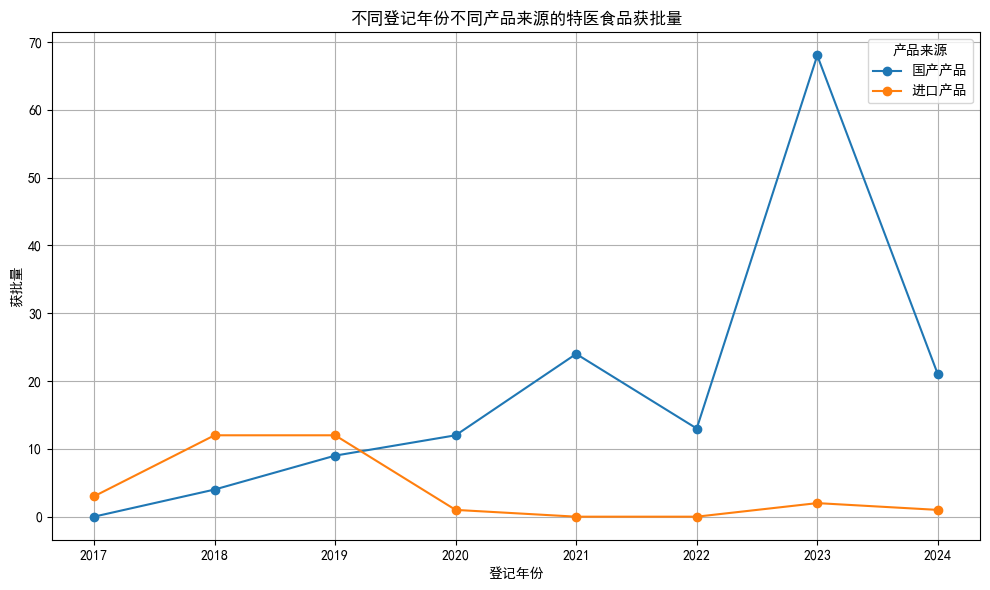

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] 
plt.rcParams['axes.unicode_minus']=False 

# 读取最新的 result2.xlsx 文件
file_path = r"D:\python练习\泰迪杯数据分析B\result2.xlsx"  
data_df = pd.read_excel(file_path)

# 按“登记年份”和“产品来源”分组统计特医食品获批量
approval_stats = data_df.groupby(['登记年份', '产品来源']).size().unstack(fill_value=0)

# 绘制双折线图
plt.figure(figsize=(10, 6))
for source in approval_stats.columns:
    plt.plot(approval_stats.index, approval_stats[source], marker='o', label=source)

plt.title('不同登记年份不同产品来源的特医食品获批量')
plt.xlabel('登记年份')
plt.ylabel('获批量')
plt.legend(title='产品来源')
plt.grid(True)
plt.tight_layout()

# 显示图表
plt.show()


In [ ]:
# 任务2.2

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


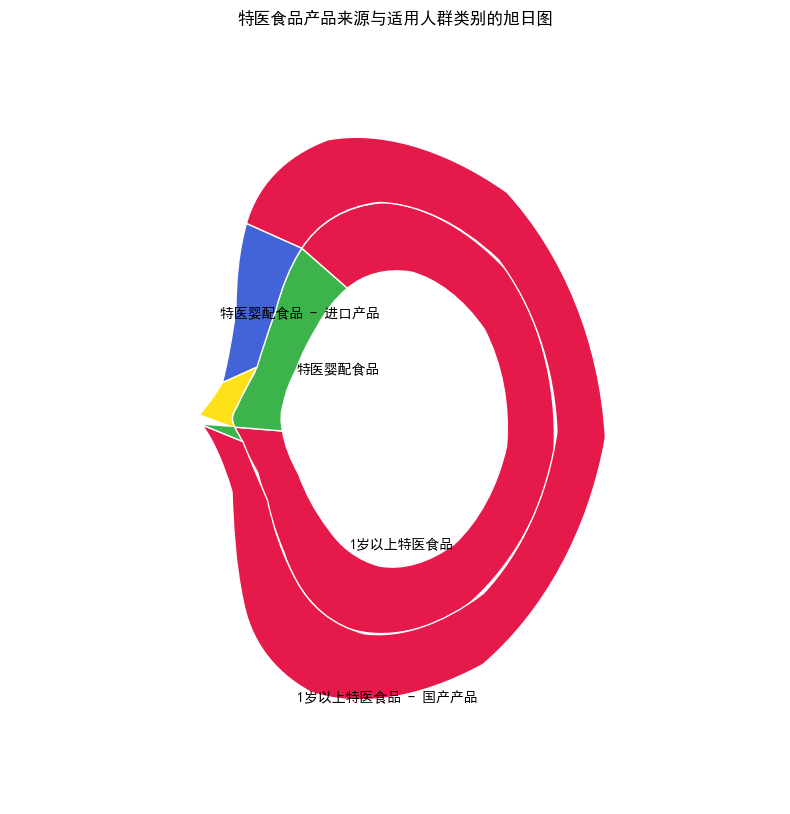

In [98]:
import matplotlib.pyplot as plt

# 根据特医食品的“产品来源”和“适用人群类别”统计数据
sunburst_data = data_df.groupby(['适用人群类别', '产品来源']).size().unstack(fill_value=0)

# 设置颜色
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6']

# 绘制旭日图
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 内层饼图表示适用人群类别
inner_values = sunburst_data.sum(axis=1)
inner_labels = inner_values.index
ax.pie(inner_values, radius=1, labels=inner_labels, colors=colors[:len(inner_values)], 
       wedgeprops=dict(width=0.3, edgecolor='w'), labeldistance=0.7)

# 外层饼图表示适用人群类别的产品来源分布
outer_values = sunburst_data.values.flatten()
outer_labels = [f"{outer_category} - {source}" for outer_category in sunburst_data.index 
                for source in sunburst_data.columns]
ax.pie(outer_values, radius=1.3, labels=outer_labels, colors=colors[:len(outer_values)],
       wedgeprops=dict(width=0.3, edgecolor='w'), labeldistance=1.1)

# 设置标题
plt.title("特医食品产品来源与适用人群类别的旭日图", va='bottom')
plt.show()


In [ ]:
# 任务2.3

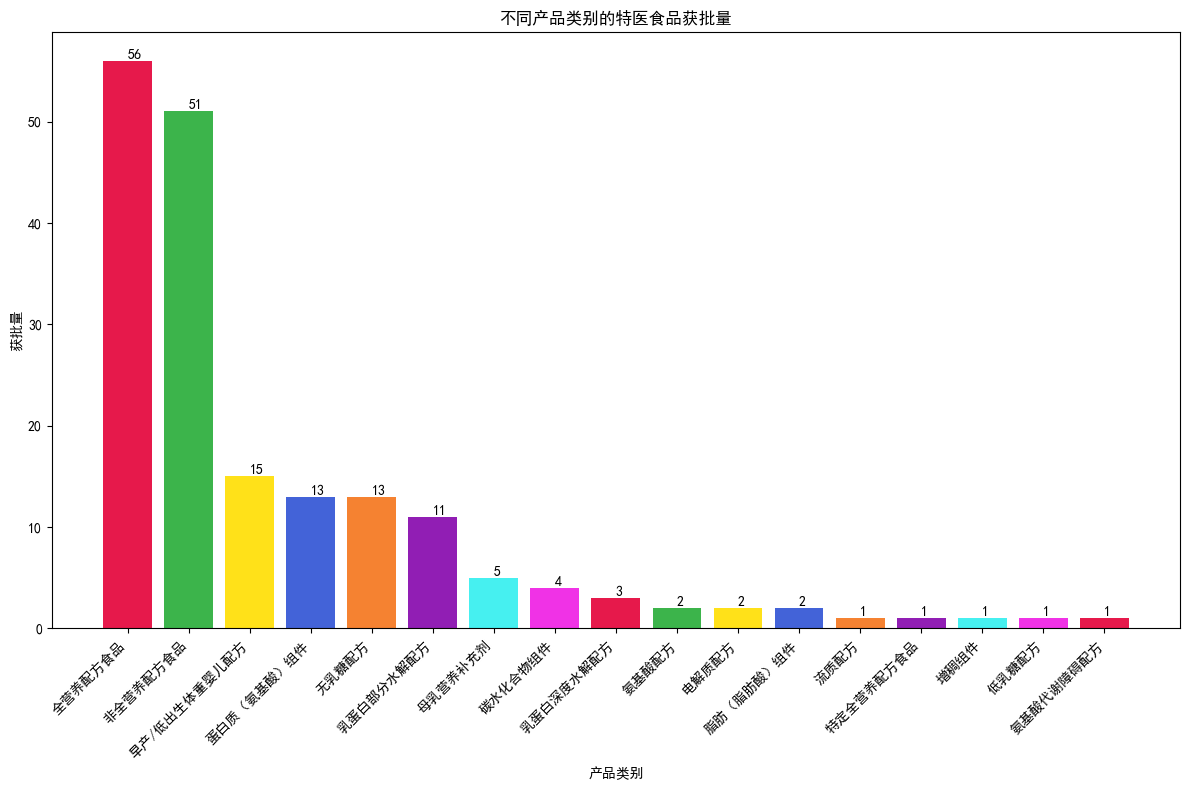

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
file_path = r"D:\python练习\泰迪杯数据分析B\result2.xlsx"  
data_df = pd.read_excel(file_path)

# 按“产品类别”分组统计特医食品获批量
approval_stats = data_df.groupby('产品类别')['产品名称'].count().sort_values(ascending=False)

# 设置颜色
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6']

# 绘制柱状图
plt.figure(figsize=(12, 8))
bars = plt.bar(approval_stats.index, approval_stats.values, color=colors[:len(approval_stats)])

# 添加数值标签
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom')  # 添加数值标签

plt.title('不同产品类别的特医食品获批量')
plt.xlabel('产品类别')
plt.ylabel('获批量')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 显示图表
plt.show()


In [ ]:
# 任务2.4

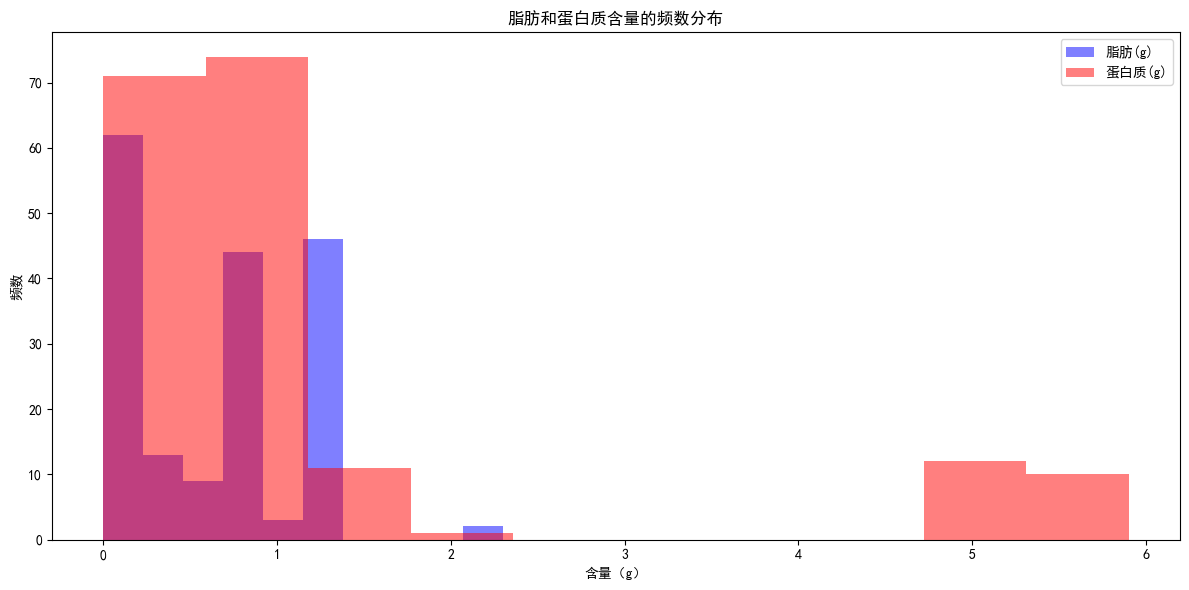

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
new_file_path = "result1.xlsx"
df = pd.read_excel(new_file_path)

# 设置图形大小
plt.figure(figsize=(12, 6))

# 绘制脂肪含量的直方图
plt.hist(df['脂肪(g)'], bins=10, color='blue', alpha=0.5, label='脂肪(g)')

# 绘制蛋白质含量的直方图
plt.hist(df['蛋白质(g)'], bins=10, color='red', alpha=0.5, label='蛋白质(g)')

# 添加标题和标签
plt.title("脂肪和蛋白质含量的频数分布")
plt.xlabel("含量（g）")
plt.ylabel("频数")

# 添加图例
plt.legend()
plt.tight_layout()
# 显示图形
plt.show()



In [ ]:
# 任务2.5

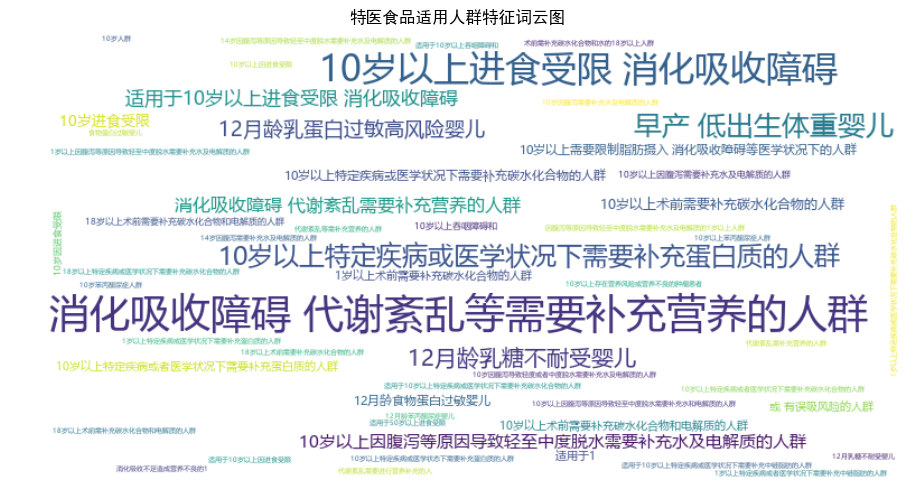

In [101]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 读取数据
file_path = r"D:\python练习\泰迪杯数据分析B\泰迪杯B代码\result2.xlsx"
data_df = pd.read_excel(file_path)

# 合并所有适用人群类别为一个字符串
all_categories = ' '.join(data_df['适用人群'])

# 生成词云
wordcloud = WordCloud(font_path='msyh.ttc',  # 指定字体路径，确保支持中文显示
                      stopwords={},        # 停用词列表，可以根据需要添加
                      background_color='white',
                      width=800, height=400).generate(all_categories)

# 显示词云图
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 不显示坐标轴
plt.title('特医食品适用人群特征词云图')
plt.tight_layout()

# 显示图表
plt.show()



In [ ]:
# 任务3.1

In [102]:
import pandas as pd

data_df = pd.read_excel(file_path)

# 定义推荐函数
def recommend_products(age_group=None, symptom=None, special_note=None):
    """
    根据客户的需求条件推荐特医食品。
    
    参数:
    - age_group (str): 年龄段，如 "婴儿" 或 "1岁以上"
    - symptom (str): 特定症状，如 "过敏" 或 "肠胃"
    - special_note (dict): 特殊说明，例如 {"产品来源": "进口产品", "组织状态": "粉状"}
    
    返回:
    - DataFrame: 符合条件的产品选项
    """
    # 初始化筛选条件
    filtered_df = data_df
    
    # 根据年龄段筛选
    if age_group:
        if age_group == "婴儿":
            filtered_df = filtered_df[filtered_df['适用人群类别'] == '特医婴配食品']
        elif age_group == "1岁以上":
            filtered_df = filtered_df[filtered_df['适用人群类别'] == '1岁以上特医食品']
    
    # 根据症状筛选
    if symptom:
        filtered_df = filtered_df[filtered_df['适用人群'].str.contains(symptom, na=False)]
    
    # 根据特殊说明筛选
    if special_note:
        for key, value in special_note.items():
            if key in filtered_df.columns:
                filtered_df = filtered_df[filtered_df[key] == value]
    
    # 如果没有找到符合条件的产品，返回提示信息
    if filtered_df.empty:
        print("未找到符合条件的特医食品。")
        return pd.DataFrame()  # 返回空的 DataFrame
    
    # 返回符合条件的产品选项
    return filtered_df[['企业名称', '产品名称', '注册证号', '产品类别', '组织状态', '适用人群', '产品来源', '登记年份']]

# 示例用法
# 客户需求示例：0-12月龄婴儿，食物过敏，要求进口产品
recommended_products = recommend_products(
    age_group="婴儿",
    symptom="过敏",
    special_note={"产品来源": "进口产品"}
)

# 显示推荐的产品
recommended_products


,企业名称,产品名称,注册证号,产品类别,组织状态,适用人群,产品来源,登记年份
0,SHS INTERNATIONAL LTD,纽康特特殊医学用途婴儿氨基酸配方食品,国食注字TY20175001,氨基酸配方,粉状,食物蛋白过敏婴儿,进口产品,2017
1,ABBOTT LABORATORIES S.A.,雅培亲护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2017
2,ABBOTT LABORATORIES S.A.,菁挚呵护特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20175003,乳蛋白部分水解配方,粉状,0-12月龄乳蛋白过敏高风险婴儿,进口产品,2017
5,MEAD JOHNSON B.V.,亲舒特殊医学用途婴儿乳蛋白部分水解配方粉,国食注字TY20185002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2018
17,NESTLE NEDERLAND B.V.,蔼儿舒特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20185012,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2018
20,Nestlé Deutschland AG,超启能恩特殊医学用途婴儿乳蛋白部分水解配方食品,国食注字TY20195002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2019
36,Nestle Nederland B.V.,肽敏舒ALTHÉRA®特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20195010,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2019
46,Nestle Nederland B.V.,恩敏舒特殊医学用途婴儿氨基酸配方食品,国食注字TY20205001,氨基酸配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2020
96,Nutricia Cuijk B.V.,纽太特特殊医学用途婴儿乳蛋白深度水解配方食品,国食注字TY20235001,乳蛋白深度水解配方,粉状,0～12月龄食物蛋白过敏婴儿,进口产品,2023
135,雀巢德国有限公司,启赋®敏适特殊医学用途婴儿乳蛋白部分水解配方食品,国食注字TY20235002,乳蛋白部分水解配方,粉状,0～12月龄乳蛋白过敏高风险婴儿,进口产品,2023
